# Análisis exploratorio de BD Dengue

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [4]:
# Cargar BD
df_total = pd.read_excel(r"C:\Users\usuario1\OneDrive - Universidad de Antioquia\UNIVERSIDAD DE ANTIOQUIA\Proyecto SAT Dengue\Bases de datos\Secretaria de salud\BD_DENGUE_2021-2025.xlsx")
df_total.head()

,cod_eve,fec_not,ini_sin_,semana,año,cod_pre,cod_sub,edad_,uni_med_,nacionali_,...,nom_upgd,npais_proce,ndep_proce,nmun_proce,npais_resi,ndep_resi,nmun_resi,ndep_notif,nmun_notif,nreg
0,210,2021-01-11,2021-01-07,1,2021,515402201,1,40,1,170,...,ESE HOSPITAL CESAR URIBE PIEDRAHITA,COLOMBIA,ANTIOQUIA,EL BAGRE,COLOMBIA,ANTIOQUIA,EL BAGRE,ANTIOQUIA,CAUCASIA,1800
1,210,2021-02-16,2021-01-21,3,2021,526605568,10,38,1,170,...,SIN INFORMACIÓN,COLOMBIA,ANTIOQUIA,CAUCASIA,COLOMBIA,ANTIOQUIA,ENVIGADO,SIN INFORMACIÓN,SIN INFORMACIÓN,1793
2,210,2021-02-06,2021-02-01,5,2021,515402201,1,12,1,170,...,ESE HOSPITAL CESAR URIBE PIEDRAHITA,COLOMBIA,ANTIOQUIA,ZARAGOZA,COLOMBIA,ANTIOQUIA,ZARAGOZA,ANTIOQUIA,CAUCASIA,1791
3,210,2021-02-19,2021-02-08,6,2021,526605568,10,54,1,170,...,SIN INFORMACIÓN,COLOMBIA,ANTIOQUIA,CAUCASIA,COLOMBIA,BOGOTA,BOGOTA,SIN INFORMACIÓN,SIN INFORMACIÓN,1795
4,210,2021-02-12,2021-02-10,6,2021,2548885069,80,25,1,170,...,SIN INFORMACIÓN,COLOMBIA,CUNDINAMARCA,NILO,COLOMBIA,ANTIOQUIA,CAUCASIA,SIN INFORMACIÓN,SIN INFORMACIÓN,1798


In [5]:
# Revisar valores nulos
df_total.isnull().sum()

cod_eve       0
fec_not       0
ini_sin_      0
semana        0
año           0
             ..
ndep_resi     0
nmun_resi     0
ndep_notif    0
nmun_notif    0
nreg          0
Length: 120, dtype: int64

In [3]:
df_caucasia = pd.read_excel(r"C:\Users\usuario1\OneDrive - Universidad de Antioquia\UNIVERSIDAD DE ANTIOQUIA\Proyecto SAT Dengue\Bases de datos\Secretaria de salud\BD_DENGUE_2021-2025_CAUCASIA.xlsx")
df_caucasia.head()

,ini_sin_,semana,año,area_,localidad_,cen_pobla_,vereda_,bar_ver_,dir_res_,nmun_proce,nmun_resi
0,2021-01-21,3,2021,2,NO APLICA,CAUCASIA,NO APLICA,CAUCASIA,CR 39 E 48 C SUR 36,CAUCASIA,ENVIGADO
1,2021-02-08,6,2021,2,NO APLICA,CAUCASIA,NO APLICA,CAUCASIA,CL 29 A 42-99,CAUCASIA,BOGOTA
2,2021-02-19,7,2021,1,VILLA GRANDA,NO APLICA,NO APLICA,VILLA GRANDA,VILLA GRANDA,CAUCASIA,CAUCASIA
3,2021-03-06,9,2021,3,NO APLICA,NO APLICA,CUTURÚ,CUTURÚ,CUTURU,CAUCASIA,CAUCASIA
4,2021-03-28,13,2021,1,LA YE,NO APLICA,NO APLICA,LA YE,LA Y CARRERA 22 33 19,CAUCASIA,CAUCASIA


In [4]:
# Ver estructura de la base de datos
df_caucasia.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6117 entries, 0 to 6116
Data columns (total 11 columns):
 #   Column      Non-Null Count  Dtype         
---  ------      --------------  -----         
 0   ini_sin_    6117 non-null   datetime64[ns]
 1   semana      6117 non-null   int64         
 2   año         6117 non-null   int64         
 3   area_       6117 non-null   int64         
 4   localidad_  6117 non-null   object        
 5   cen_pobla_  6117 non-null   object        
 6   vereda_     6117 non-null   object        
 7   bar_ver_    6117 non-null   object        
 8   dir_res_    6117 non-null   object        
 9   nmun_proce  6117 non-null   object        
 10  nmun_resi   6117 non-null   object        
dtypes: datetime64[ns](1), int64(3), object(7)
memory usage: 525.8+ KB


In [5]:
# Revisar valores nulos
df_caucasia.isnull().sum()

ini_sin_      0
semana        0
año           0
area_         0
localidad_    0
cen_pobla_    0
vereda_       0
bar_ver_      0
dir_res_      0
nmun_proce    0
nmun_resi     0
dtype: int64

In [6]:
# Convertir la columna 'ini_sin_' a formato de fecha
df_caucasia['ini_sin_'] = pd.to_datetime(df_caucasia['ini_sin_'], errors='coerce')

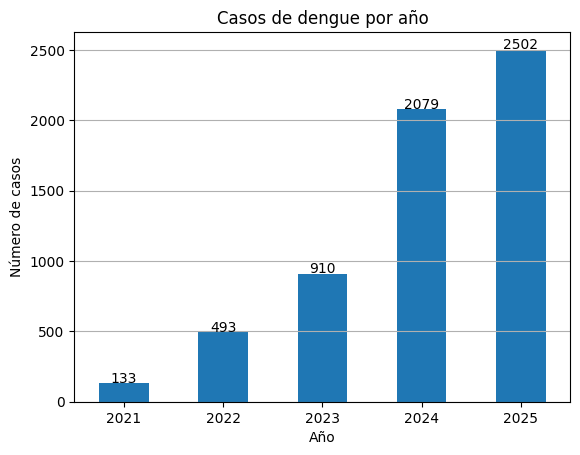

In [7]:
# Casos por año
casos_año = df_caucasia['año'].value_counts().sort_index()

plt.figure()

ax = casos_año.plot(kind='bar')

plt.title("Casos de dengue por año")
plt.xlabel("Año")
plt.ylabel("Número de casos")
plt.xticks(rotation=0)
plt.grid(axis='y')

# Mostrar valores sobre cada barra
for i, v in enumerate(casos_año):
    ax.text(i, v + 5, str(v), ha='center')

plt.show()

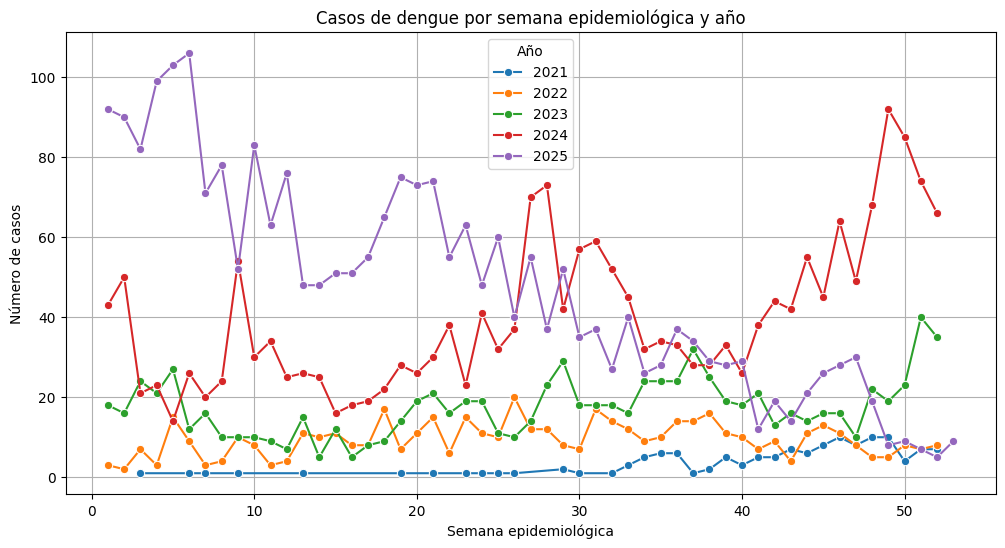

In [8]:
# Casos por semana epidemiológica por año
plt.figure(figsize=(12, 6))
casos_semana = df_caucasia.groupby(['año', 'semana']).size().reset_index(name='num_casos')

sns.lineplot(
    data=casos_semana,
    x='semana',
    y='num_casos',
    hue='año',
    marker='o',
    palette='tab10'  # Colores más contrastantes
)

plt.title("Casos de dengue por semana epidemiológica y año")
plt.xlabel("Semana epidemiológica")
plt.ylabel("Número de casos")
plt.legend(title='Año')
plt.grid()
plt.show()


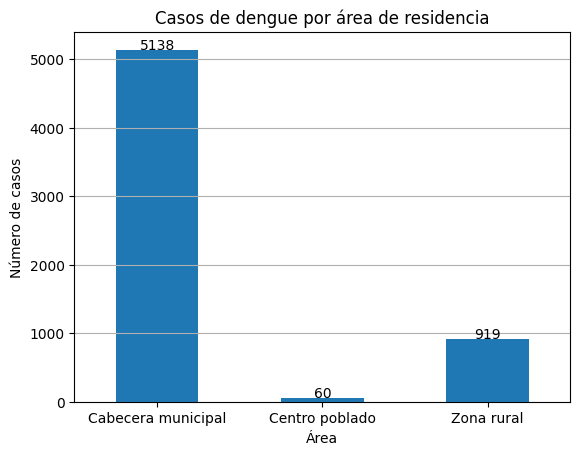

In [9]:
# Analizar casos por área
casos_area = df_caucasia['area_'].value_counts().sort_index()

# Reemplazar códigos por nombres
casos_area.index = ['Cabecera municipal', 'Centro poblado', 'Zona rural']

plt.figure()

ax = casos_area.plot(kind='bar')

plt.title("Casos de dengue por área de residencia")
plt.xlabel("Área")
plt.ylabel("Número de casos")
plt.xticks(rotation=0)
plt.grid(axis='y')

# Mostrar número de casos sobre cada barra
for i, v in enumerate(casos_area):
    ax.text(i, v + 5, str(v), ha='center')

plt.show()

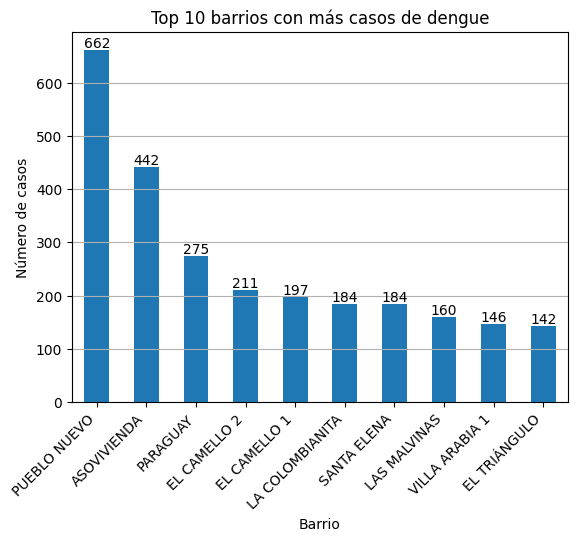

In [10]:
barrios = df_caucasia['bar_ver_'].value_counts().head(10)

plt.figure()

barrios.plot(kind='bar')

plt.title("Top 10 barrios con más casos de dengue")
plt.xlabel("Barrio")
plt.ylabel("Número de casos")

plt.xticks(rotation=45, ha='right')
plt.grid(axis='y')

# Mostrar número de casos sobre cada barra
for i, v in enumerate(barrios):
    plt.text(i, v + 5, str(v), ha='center')

plt.show()

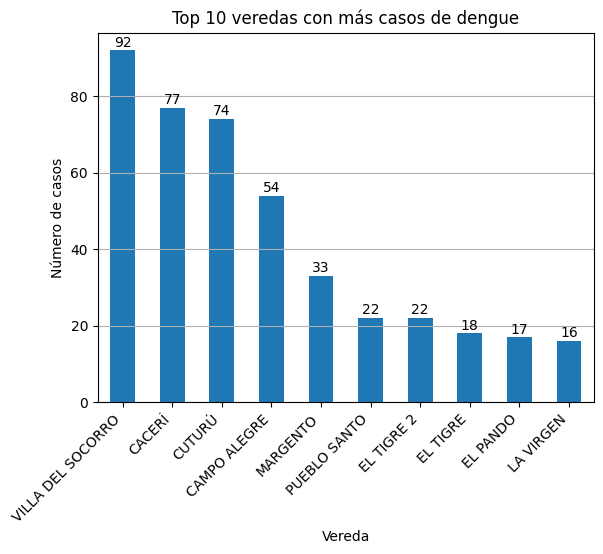

In [11]:
# Veredas con más casos excluyendo "no aplica"
veredas = df_caucasia[df_caucasia['vereda_'] != 'NO APLICA']['vereda_'].value_counts().head(10) 
plt.figure()
veredas.plot(kind='bar')
plt.title("Top 10 veredas con más casos de dengue")
plt.xlabel("Vereda")
plt.ylabel("Número de casos")
plt.xticks(rotation=45, ha='right')
plt.grid(axis='y')
for i, v in enumerate(veredas):
    plt.text(i, v + 1, str(v), ha='center')
plt.show()

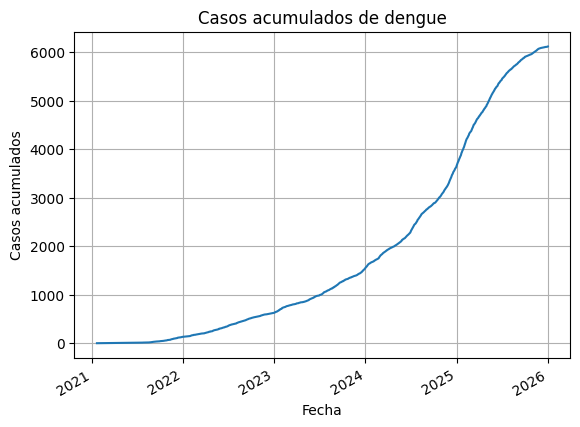

In [12]:
# Casos acumulados por fecha de notificación
casos_fecha = df_caucasia.groupby('ini_sin_').size()

casos_acumulados = casos_fecha.cumsum()

plt.figure()

casos_acumulados.plot()

plt.title("Casos acumulados de dengue")

plt.xlabel("Fecha")

plt.ylabel("Casos acumulados")
plt.grid()

plt.show()

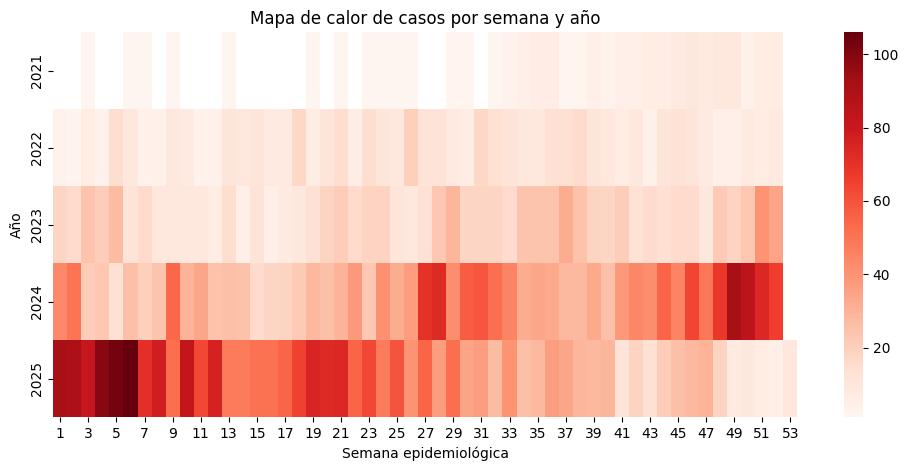

In [13]:
# Heatmap de semanas por año
tabla = df_caucasia.groupby(['año','semana']).size().unstack()

plt.figure(figsize=(12,5))

sns.heatmap(tabla, cmap="Reds")

plt.title("Mapa de calor de casos por semana y año")

plt.xlabel("Semana epidemiológica")

plt.ylabel("Año")

plt.show()

# Reemuestreo

In [85]:
import pandas as pd

# 1. Crear el rango de domingos (Semana Epi) desde el inicio al fin
rango_fechas = pd.date_range(start='2021-01-03', end='2025-12-28', freq='W-SUN')

# 2. Crear el DataFrame maestro con la estructura correcta
df_maestro = pd.DataFrame({'fecha': rango_fechas})
df_maestro['año'] = df_maestro['fecha'].dt.year

# 3. Calcular la semana_epi respetando que el 2025 llega a la 53
# Usamos un groupby por año para numerar las semanas del 1 en adelante
df_maestro['semana_epi'] = df_maestro.groupby('año').cumcount() + 1

# 4. Unir con tus datos (df_epi) y llenar vacíos con 0
df_epi = pd.merge(df_maestro, df_epi.reset_index(), on=['fecha', 'año'], how='left')
df_epi['num_casos'] = df_epi['num_casos'].fillna(0).astype(int)

# 5. Limpieza final
df_epi['semana_epi'] = df_epi['semana_epi_y'].combine_first(df_epi['semana_epi_x']).astype(int)
df_epi = df_epi[['fecha', 'año', 'semana_epi', 'num_casos']].set_index('fecha')

print(df_epi.head(20))

print(df_epi.tail(20))

             año  semana_epi  num_casos
fecha                                  
2021-01-03  2021           1          0
2021-01-10  2021           2          0
2021-01-17  2021           3          1
2021-01-24  2021           4          0
2021-01-31  2021           5          0
2021-02-07  2021           6          1
2021-02-14  2021           7          1
2021-02-21  2021           8          0
2021-02-28  2021           9          1
2021-03-07  2021          10          0
2021-03-14  2021          11          0
2021-03-21  2021          12          0
2021-03-28  2021          13          1
2021-04-04  2021          14          0
2021-04-11  2021          15          0
2021-04-18  2021          16          0
2021-04-25  2021          17          0
2021-05-02  2021          18          0
2021-05-09  2021          19          1
2021-05-16  2021          20          0
             año  semana_epi  num_casos
fecha                                  
2025-08-17  2025          34         26


# Datos meteorológicos

In [63]:
df_meteo = pd.read_excel(r"C:\Users\usuario1\OneDrive - Universidad de Antioquia\UNIVERSIDAD DE ANTIOQUIA\Proyecto SAT Dengue\Bases de datos\Datos meteorológicos\Datos_NS_2021-2025.xlsx")
df_meteo.head()

,YEAR,DOY,T2M,T2M_MAX,T2M_MIN,QV2M,RH2M,PRECTOTCORR,WS2M,WS2M_MAX,WS2M_MIN,ALLSKY_SFC_UV_INDEX
0,2021,3,28.64,35.09,23.84,17.89,75.41,4.03,0.14,0.32,0.07,2.48
1,2021,4,28.48,35.05,23.69,15.91,68.69,0.70,0.14,0.25,0.07,2.47
2,2021,5,27.84,34.96,22.71,15.16,68.47,0.62,0.16,0.34,0.03,2.30
3,2021,6,28.58,35.31,23.50,15.64,67.09,0.00,0.11,0.22,0.04,2.34
4,2021,7,28.52,34.44,23.73,15.94,67.92,0.04,0.11,0.22,0.05,2.03


In [64]:
# Renombrar columnas del dataframe nasa
df_meteo.rename(columns={
    'YEAR': 'año',
    'DOY': 'dia',
    'T2M': 'temp',
    'T2M_MAX': 'temp_max',
    'T2M_MIN': 'temp_min',
    'QV2M': 'hum_esp',
    'RH2M': 'hum_rel',
    'PRECTOTCORR': 'prec',
    'WS2M': 'vel_vi',
    'WS2M_MAX': 'vel_vi_max',
    'WS2M_MIN': 'vel_vi_min',
    'ALLSKY_SFC_UV_INDEX': 'uv'
}, inplace=True)
df_meteo.head(3)

,año,dia,temp,temp_max,temp_min,hum_esp,hum_rel,prec,vel_vi,vel_vi_max,vel_vi_min,uv
0,2021,3,28.64,35.09,23.84,17.89,75.41,4.03,0.14,0.32,0.07,2.48
1,2021,4,28.48,35.05,23.69,15.91,68.69,0.70,0.14,0.25,0.07,2.47
2,2021,5,27.84,34.96,22.71,15.16,68.47,0.62,0.16,0.34,0.03,2.30


In [65]:
# Asegurar que las columnas 'año' y 'dia' sean numéricas 
df_meteo["año"] = df_meteo["año"].astype(int)
df_meteo["dia"] = df_meteo["dia"].astype(int)

# Crear la columna 'fecha' combinando año y día del año 
df_meteo["fecha"] = pd.to_datetime(df_meteo["año"].astype(str), format="%Y") + pd.to_timedelta(df_meteo["dia"] - 1, unit="D")

# Eliminar las columnas originales 'año' y 'dia'
df_meteo = df_meteo.drop(columns=[ "dia"])

# Reordenar las columnas para que 'fecha' quede al inicio 
cols = ["fecha"] + [c for c in df_meteo.columns if c != "fecha"]
df_meteo = df_meteo[cols]

# Ordenar cronológicamente 
df_meteo_crono = df_meteo.sort_values("fecha").reset_index(drop=True)

df_meteo_crono.head()

,fecha,año,temp,temp_max,temp_min,hum_esp,hum_rel,prec,vel_vi,vel_vi_max,vel_vi_min,uv
0,2021-01-03,2021,28.64,35.09,23.84,17.89,75.41,4.03,0.14,0.32,0.07,2.48
1,2021-01-04,2021,28.48,35.05,23.69,15.91,68.69,0.70,0.14,0.25,0.07,2.47
2,2021-01-05,2021,27.84,34.96,22.71,15.16,68.47,0.62,0.16,0.34,0.03,2.30
3,2021-01-06,2021,28.58,35.31,23.50,15.64,67.09,0.00,0.11,0.22,0.04,2.34
4,2021-01-07,2021,28.52,34.44,23.73,15.94,67.92,0.04,0.11,0.22,0.05,2.03


In [78]:
df_meteo_crono.columns

Index(['fecha', 'año', 'temp', 'temp_max', 'temp_min', 'hum_esp', 'hum_rel',
       'prec', 'vel_vi', 'vel_vi_max', 'vel_vi_min', 'uv'],
      dtype='object')

In [79]:
# Creamos la columna 'lluvia' (1 si hubo >= 1mm, 0 si no)
df_meteo['lluvia'] = (df_meteo['prec'] >= 1).astype(int)

In [84]:
# 1. Asegurar formato y crear variable de lluvia
df_meteo['fecha'] = pd.to_datetime(df_meteo['fecha'])
df_meteo['dias_lluvia'] = (df_meteo['prec'] >= 1).astype(int)

# 2. Calcular el domingo correspondiente a cada día (Domingo INS)
df_meteo['fecha_semana'] = df_meteo['fecha'] - pd.to_timedelta((df_meteo['fecha'].dt.weekday + 1) % 7, unit='D')

# 3. Agrupar por 'fecha_semana' para tener valores semanales
# Usamos el diccionario de reglas que acordamos antes
reglas = {
    'temp': 'mean', 'temp_max': 'mean', 'temp_min': 'mean',
    'hum_esp': 'mean', 'hum_rel': 'mean', 
    'prec': 'sum', 'dias_lluvia': 'sum',
    'vel_vi': 'mean', 'uv': 'mean'
}

df_meteo_agrupado = df_meteo.groupby('fecha_semana').agg(reglas).reset_index()
df_meteo_agrupado.tail()

,fecha_semana,temp,temp_max,temp_min,hum_esp,hum_rel,prec,dias_lluvia,vel_vi,uv
256,2025-11-30,25.527143,28.834286,23.198571,18.515714,90.502857,27.49,6,0.158571,2.065714
257,2025-12-07,26.082857,29.091429,23.785714,19.244286,90.718571,20.94,4,0.164286,2.024286
258,2025-12-14,26.020000,29.442857,23.658571,18.935714,89.791429,30.61,6,0.168571,2.067143
259,2025-12-21,25.988571,30.090000,23.008571,17.994286,85.884286,2.51,1,0.185714,1.995714
260,2025-12-28,26.085714,29.490000,23.778571,19.070000,90.110000,14.39,3,0.131429,1.842500


# Datos fusionados

In [87]:
# Fusionar los datos df_epi con df_meteo_agrupado, manteniendo fecha, semanas epidemiológicas, años y casos
df_final = pd.merge(df_epi.reset_index(), df_meteo_agrupado, left_on='fecha', right_on='fecha_semana', how='left')
df_final = df_final.drop(columns=['fecha_semana'])
df_final.head()
df_final.tail()

,fecha,año,semana_epi,num_casos,temp,temp_max,temp_min,hum_esp,hum_rel,prec,dias_lluvia,vel_vi,uv
259,2025-11-30,2025,49,8,25.527143,28.834286,23.198571,18.515714,90.502857,27.49,6,0.158571,2.065714
260,2025-12-07,2025,50,9,26.082857,29.091429,23.785714,19.244286,90.718571,20.94,4,0.164286,2.024286
261,2025-12-14,2025,51,7,26.020000,29.442857,23.658571,18.935714,89.791429,30.61,6,0.168571,2.067143
262,2025-12-21,2025,52,5,25.988571,30.090000,23.008571,17.994286,85.884286,2.51,1,0.185714,1.995714
263,2025-12-28,2025,53,9,26.085714,29.490000,23.778571,19.070000,90.110000,14.39,3,0.131429,1.842500


# Prueba de normalidad

In [88]:
from scipy.stats import shapiro

# Seleccionar solo las columnas numéricas
numericas = df_final.select_dtypes(include=["float64", "int64"]) # esto elimina la fecha de lso atributos a determinar correlacion

# Aplicar Shapiro-Wilk a cada variable
resultados_normalidad = {}
for col in numericas.columns:
    stat, p = shapiro(numericas[col].dropna())
    resultados_normalidad[col] = {"Estadístico W": stat, "Valor p": p}

# Mostrar resultados
df_normalidad = pd.DataFrame(resultados_normalidad).T
df_normalidad["Normal (p>0.05)"] = df_normalidad["Valor p"] > 0.05
df_normalidad

,Estadístico W,Valor p,Normal (p>0.05)
semana_epi,0.954454,2.356410e-07,False
num_casos,0.843577,1.226151e-15,False
temp,0.917904,7.176093e-11,False
temp_max,0.882569,2.127865e-13,False
temp_min,0.981649,1.766579e-03,False
hum_esp,0.948179,4.678979e-08,False
hum_rel,0.829663,2.432615e-16,False
prec,0.891008,7.570495e-13,False
dias_lluvia,0.885365,3.217254e-13,False
vel_vi,0.977720,3.763624e-04,False


In [89]:
# Seleccionar solo las columnas numéricas
df_numerico = df_final.select_dtypes(include=['float64', 'int64']) # esto elimina la fecha de lso atributos a determinar correlacion

# Calcular la matriz de correlación de Spearman
corr_spearman = df_numerico.corr(method='spearman')

# Mostrar matriz en consola
print("Matriz de correlación de Spearman:\n")
corr_spearman

Matriz de correlación de Spearman:



,semana_epi,num_casos,temp,temp_max,temp_min,hum_esp,hum_rel,prec,dias_lluvia,vel_vi,uv
semana_epi,1.000000,0.044844,-0.514631,-0.540996,-0.167363,0.386056,0.489667,0.206576,0.221741,0.391611,-0.085018
num_casos,0.044844,1.000000,-0.266982,-0.318098,-0.016443,0.571617,0.444176,0.304276,0.336219,0.331075,-0.199055
temp,-0.514631,-0.266982,1.000000,0.946716,0.713052,-0.426176,-0.829955,-0.556040,-0.602286,-0.644186,0.191986
temp_max,-0.540996,-0.318098,0.946716,1.000000,0.504819,-0.598853,-0.932506,-0.645194,-0.680890,-0.654016,0.086339
temp_min,-0.167363,-0.016443,0.713052,0.504819,1.000000,0.158653,-0.331055,-0.181030,-0.227880,-0.348537,0.333722
hum_esp,0.386056,0.571617,-0.426176,-0.598853,0.158653,1.000000,0.769104,0.595256,0.589257,0.535764,0.114110
hum_rel,0.489667,0.444176,-0.829955,-0.932506,-0.331055,0.769104,1.000000,0.713085,0.740978,0.626746,-0.031190
prec,0.206576,0.304276,-0.556040,-0.645194,-0.181030,0.595256,0.713085,1.000000,0.814484,0.357455,0.100595
dias_lluvia,0.221741,0.336219,-0.602286,-0.680890,-0.227880,0.589257,0.740978,0.814484,1.000000,0.386289,0.092853
vel_vi,0.391611,0.331075,-0.644186,-0.654016,-0.348537,0.535764,0.626746,0.357455,0.386289,1.000000,-0.006255


In [91]:
# Mostrar correlación de cada variable con casos de dengue
print("\nCorrelación de Spearman con casos de dengue:\n")
corr_spearman['num_casos'].sort_values(ascending=False)


Correlación de Spearman con casos de dengue:



num_casos      1.000000
hum_esp        0.571617
hum_rel        0.444176
dias_lluvia    0.336219
vel_vi         0.331075
prec           0.304276
semana_epi     0.044844
temp_min      -0.016443
uv            -0.199055
temp          -0.266982
temp_max      -0.318098
Name: num_casos, dtype: float64

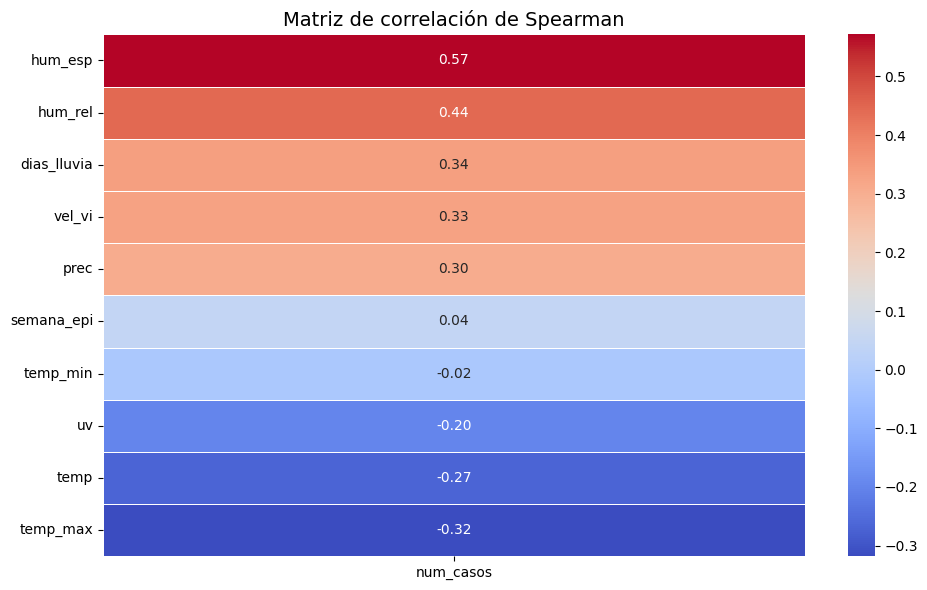

In [96]:
# Crear el mapa de calor
plt.figure(figsize=(10,6))
sns.heatmap(corr_spearman[['num_casos']].sort_values(by='num_casos', ascending=False)[1:], 
    annot=True,
    cmap='coolwarm',
    fmt=".2f",
    linewidths=0.5
)
plt.title('Matriz de correlación de Spearman', fontsize=14)
plt.tight_layout()
plt.show()

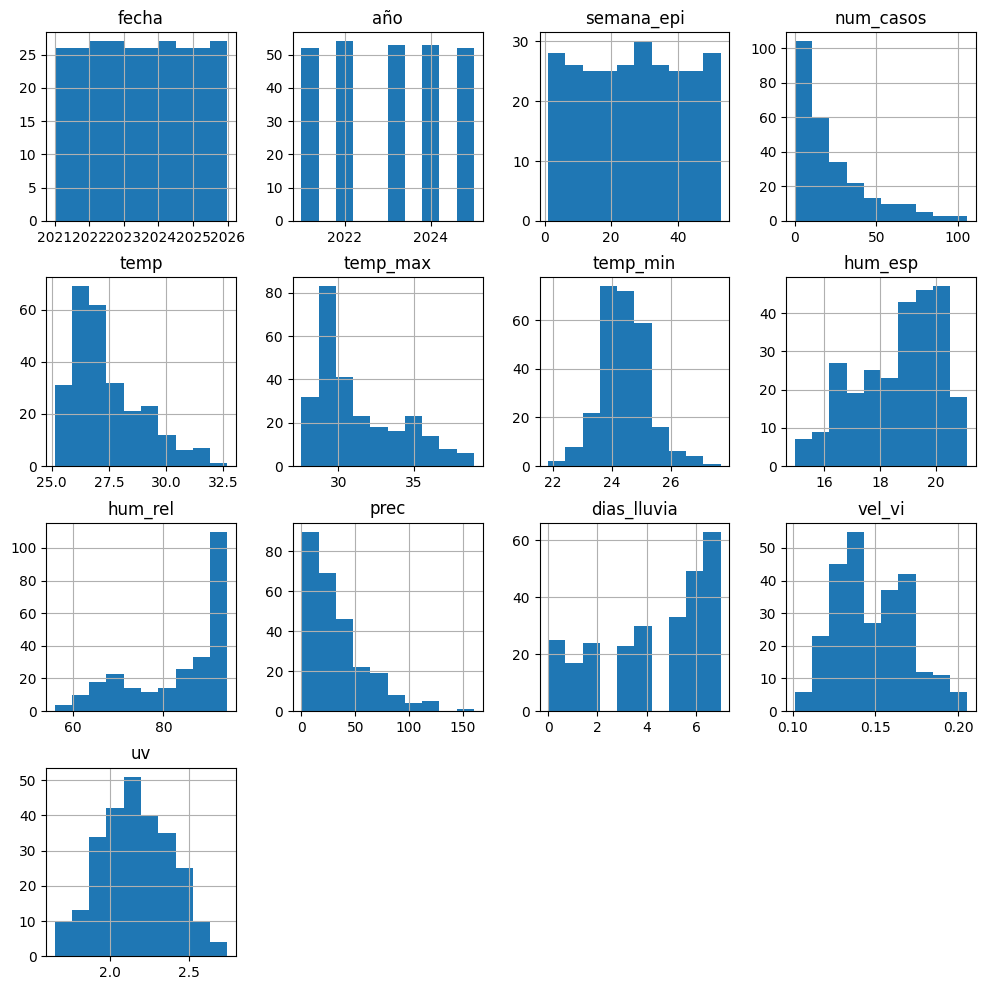

In [99]:
df_final.hist(figsize=(12,12))
plt.savefig("histogramas.png")
plt.show()

In [102]:
df_final.columns

Index(['fecha', 'año', 'semana_epi', 'num_casos', 'temp', 'temp_max',
       'temp_min', 'hum_esp', 'hum_rel', 'prec', 'dias_lluvia', 'vel_vi',
       'uv'],
      dtype='object')

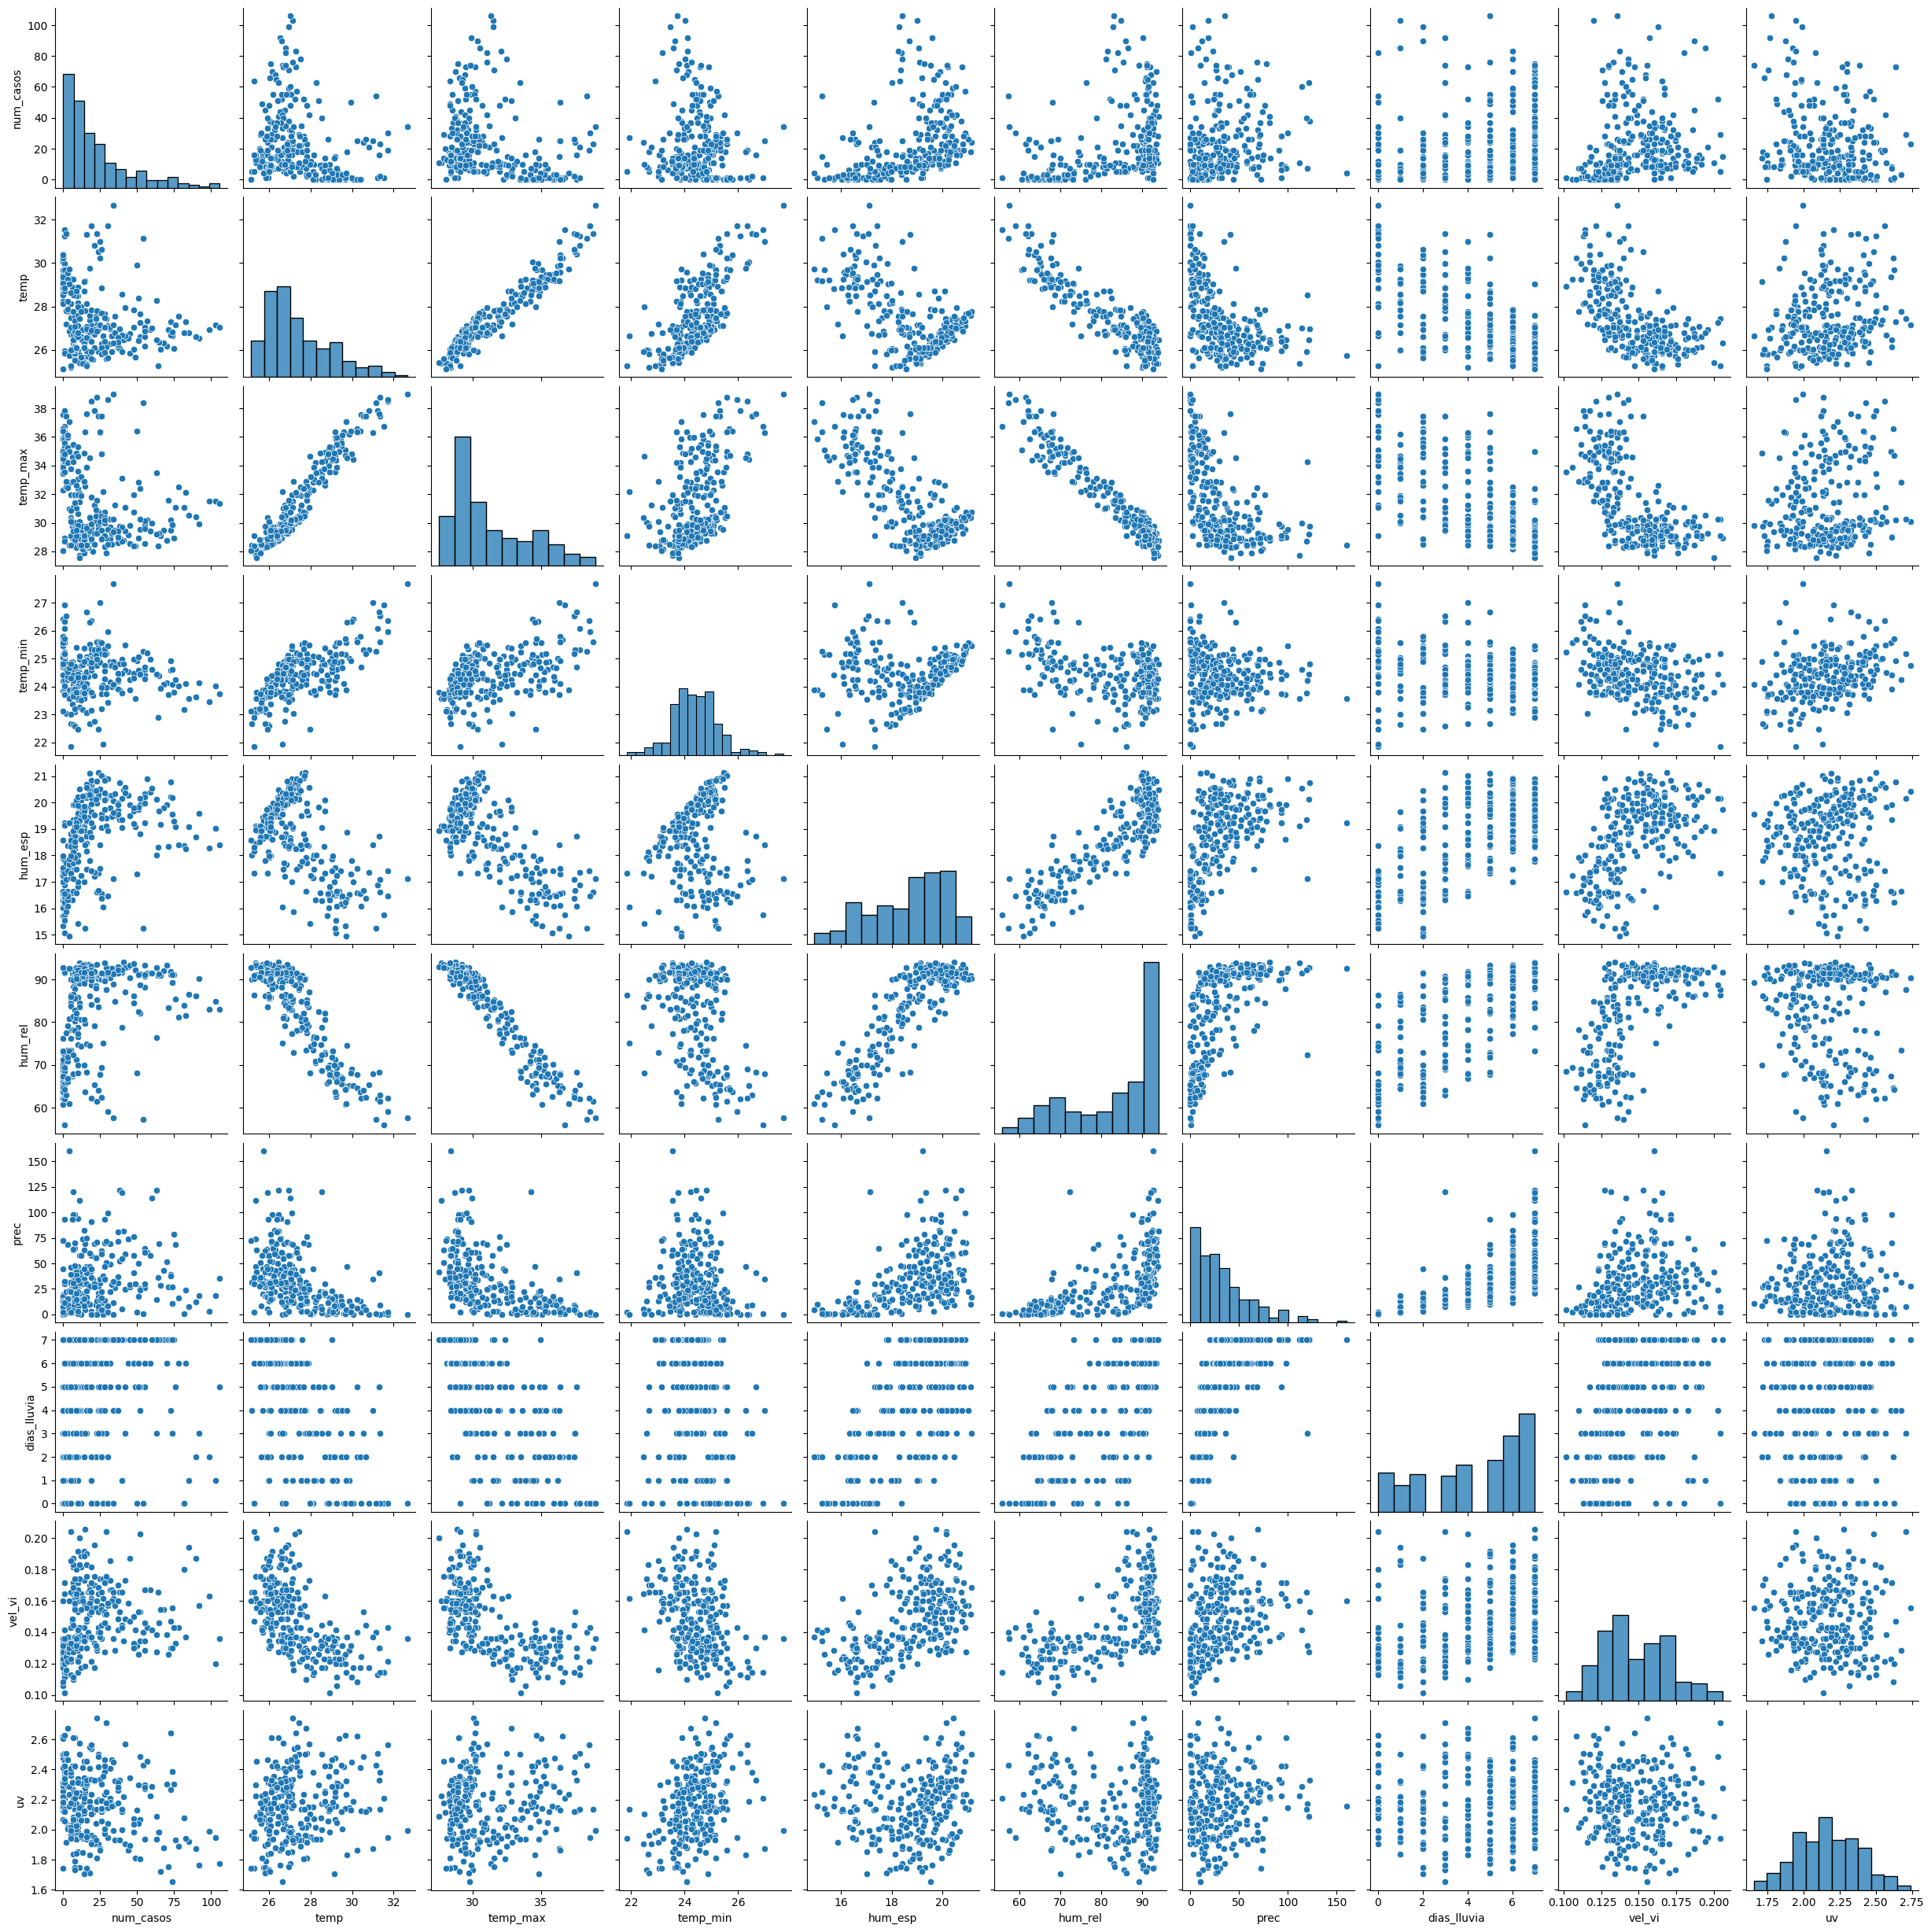

In [103]:
# graficar en una matriz todos los scaterter plots entre las variables numéricas
import seaborn as sns   
sns.pairplot(df_final[['num_casos', 'temp', 'temp_max',
       'temp_min', 'hum_esp', 'hum_rel', 'prec', 'dias_lluvia', 'vel_vi',
       'uv']])
plt.savefig("scatter_matrix.png")
plt.show()

In [104]:
import pandas as pd
import matplotlib.pyplot as plt

# Variable a analizar
variable_clima = 'prec'
max_lags = 12
correlaciones_lag = []

for lag in range(max_lags + 1):
    # Creamos la versión rezagada de la variable
    variable_lagged = df_final[variable_clima].shift(lag)
    
    # Calculamos Spearman entre casos actuales y clima del pasado
    # .corr() con method='spearman'
    corr = df_final['num_casos'].corr(variable_lagged, method='spearman')
    correlaciones_lag.append(corr)

# Crear DataFrame para visualizar
df_lags = pd.DataFrame({'Semana de Rezago': range(max_lags + 1), 'Correlación': correlaciones_lag})

C:\Users\usuario1\AppData\Local\Temp\ipykernel_1252\737723710.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Semana de Rezago', y='Correlación', data=df_lags, palette='viridis')


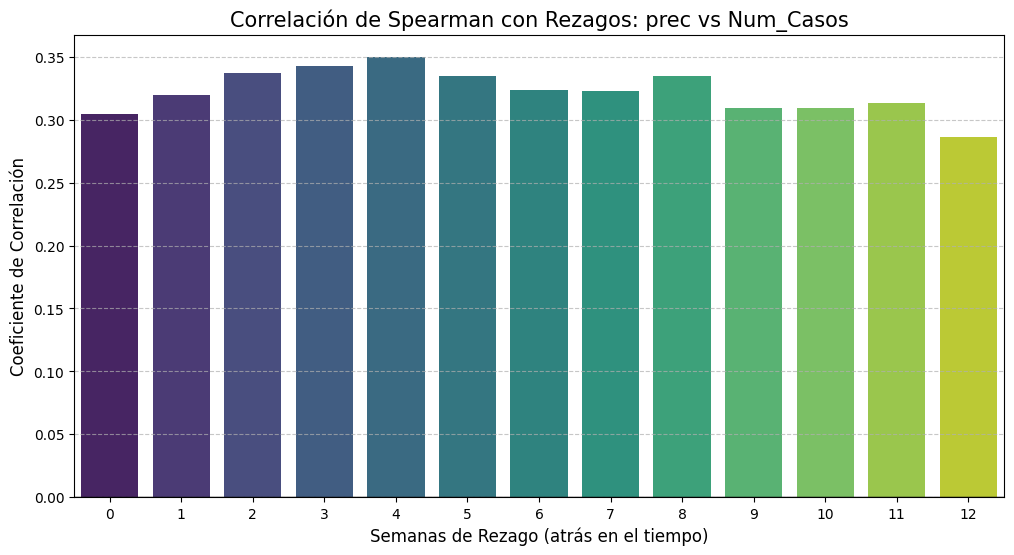

In [105]:
import seaborn as sns

# Configurar el estilo del gráfico
plt.figure(figsize=(12, 6))
sns.barplot(x='Semana de Rezago', y='Correlación', data=df_lags, palette='viridis')

# Añadir una línea de referencia en 0
plt.axhline(0, color='black', linestyle='-', linewidth=1)

# Títulos y etiquetas
plt.title(f'Correlación de Spearman con Rezagos: {variable_clima} vs Num_Casos', fontsize=15)
plt.xlabel('Semanas de Rezago (atrás en el tiempo)', fontsize=12)
plt.ylabel('Coeficiente de Correlación', fontsize=12)
plt.grid(axis='y', linestyle='--', alpha=0.7)

plt.show()